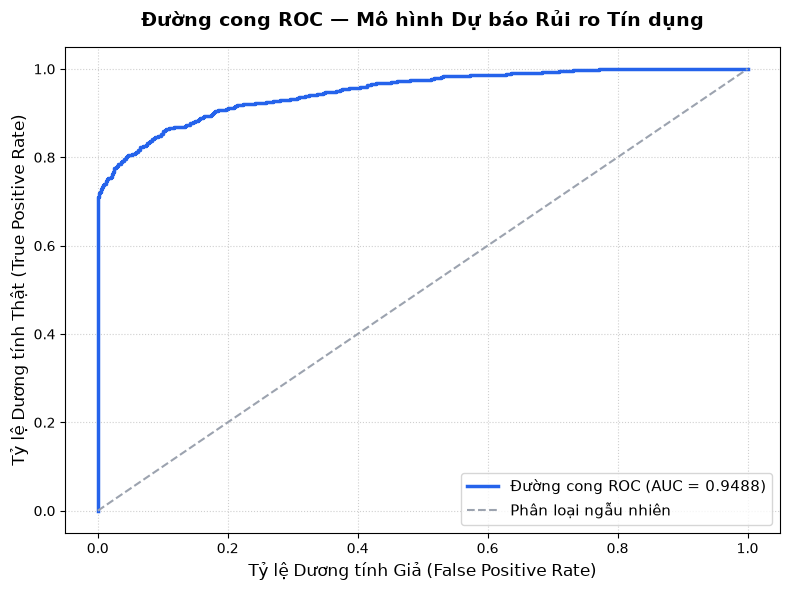

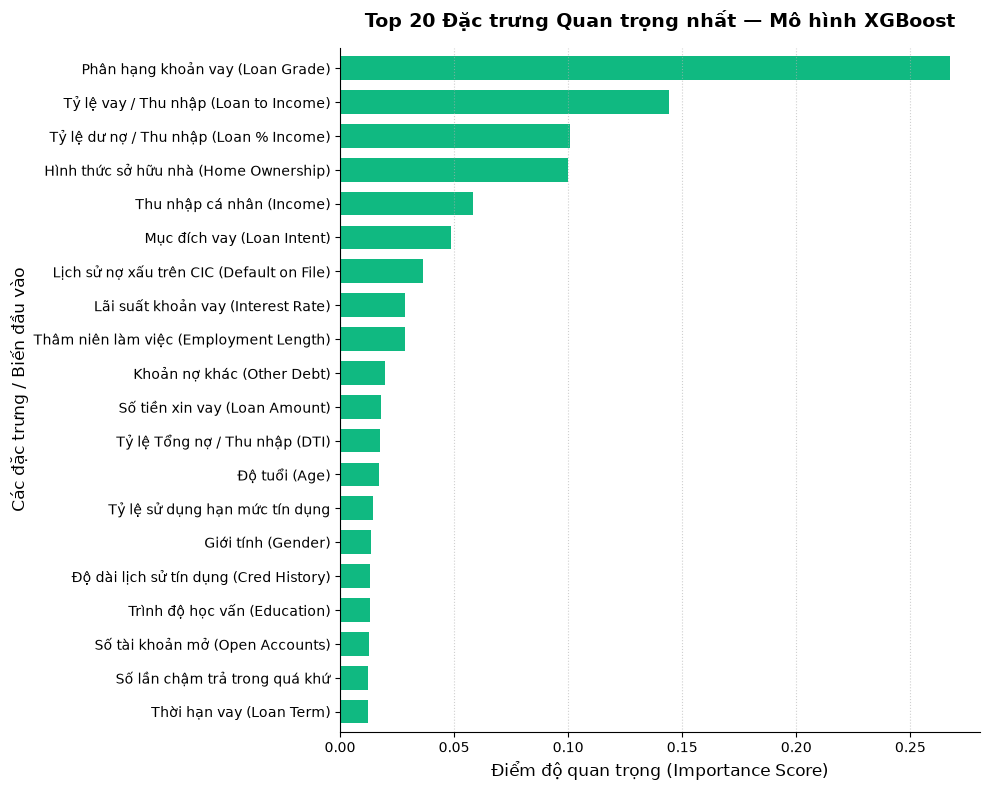

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Đường dẫn tới file JSON kết quả
metrics_path = Path("../reports/training_metrics.json") 

with open(metrics_path, "r", encoding="utf-8") as f:
    metrics = json.load(f)

# Lấy các dữ liệu đánh giá từ file JSON
auc = metrics.get("auc", 0)
fpr = metrics.get("roc_curve_data", {}).get("fpr", [])
tpr = metrics.get("roc_curve_data", {}).get("tpr", [])
feature_imp = metrics.get("feature_importance", {})

# ========================================================
# BIỂU ĐỒ 1: ĐƯỜNG CONG ROC (ROC CURVE)
# ========================================================
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="#2563EB", lw=2.5, label=f"Đường cong ROC (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color="#9CA3AF", linestyle="--", lw=1.5, label="Phân loại ngẫu nhiên")


plt.xlabel("Tỷ lệ Dương tính Giả (False Positive Rate)", fontsize=12)
plt.ylabel("Tỷ lệ Dương tính Thật (True Positive Rate)", fontsize=12)
plt.title("Đường cong ROC — Mô hình Dự báo Rủi ro Tín dụng", fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# ========================================================
# BIỂU ĐỒ 2: ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG (FEATURE IMPORTANCE)
# ========================================================

feature_translation = {
    "loan_grade": "Phân hạng khoản vay (Loan Grade)",
    "loan_to_income_ratio": "Tỷ lệ vay / Thu nhập (Loan to Income)",
    "loan_percent_income": "Tỷ lệ dư nợ / Thu nhập (Loan % Income)",
    "person_home_ownership": "Hình thức sở hữu nhà (Home Ownership)",
    "person_income": "Thu nhập cá nhân (Income)",
    "loan_intent": "Mục đích vay (Loan Intent)",
    "cb_person_default_on_file": "Lịch sử nợ xấu trên CIC (Default on File)",
    "loan_int_rate": "Lãi suất khoản vay (Interest Rate)",
    "person_emp_length": "Thâm niên làm việc (Employment Length)",
    "other_debt": "Khoản nợ khác (Other Debt)",
    "loan_amnt": "Số tiền xin vay (Loan Amount)",
    "debt_to_income_ratio": "Tỷ lệ Tổng nợ / Thu nhập (DTI)",
    "person_age": "Độ tuổi (Age)",
    "credit_utilization_ratio": "Tỷ lệ sử dụng hạn mức tín dụng",
    "gender": "Giới tính (Gender)",
    "cb_person_cred_hist_length": "Độ dài lịch sử tín dụng (Cred History)",
    "education_level": "Trình độ học vấn (Education)",
    "open_accounts": "Số tài khoản mở (Open Accounts)",
    "past_delinquencies": "Số lần chậm trả trong quá khứ",
    "loan_term_months": "Thời hạn vay (Loan Term)"
}

# Chuyển dữ liệu dict sang Pandas Series
importance_series = pd.Series(feature_imp)

# Đổi tên chỉ mục (Index) sang Tiếng Việt dựa vào dictionary
importance_series.index = [feature_translation.get(col, col) for col in importance_series.index]

# Sắp xếp và lấy top 20 đặc trưng quan trọng nhất
importance_series = importance_series.sort_values(ascending=True).tail(20)

plt.figure(figsize=(10, 8))
importance_series.plot(kind="barh", color="#10B981", width=0.7)

# Căn chỉnh giao diện Tiếng Việt
plt.title("Top 20 Đặc trưng Quan trọng nhất — Mô hình XGBoost", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Điểm độ quan trọng (Importance Score)", fontsize=12)
plt.ylabel("Các đặc trưng / Biến đầu vào", fontsize=12)
plt.grid(axis='x', linestyle=":", alpha=0.6)

# Loại bỏ viền trên và viền phải cho thoáng đẹp
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Bài toán 1: "Với hồ sơ vay này, khách hàng có khả năng vỡ nợ không?"

### Nhóm 1: Kỹ thuật Machine Learning Về Dữ liệu

Q1. Dữ liệu của bạn đến từ Kaggle — đây là dữ liệu thực tế hay dữ liệu tổng hợp? Nếu là tổng hợp, kết quả AUC 0.9488 có phản ánh đúng hiệu năng khi triển khai vào môi trường thực không?

Q2. Tỷ lệ vỡ nợ trong tập huấn luyện là 22.85% — đây là tập dữ liệu không cân bằng (Imbalanced). Tại sao bạn không áp dụng kỹ thuật như SMOTE hay Class Weight để xử lý mà vẫn dùng dữ liệu gốc?

Q3. Bạn có thực hiện Data Leakage Check chưa? Liệu các cột như loan_grade có phải là thông tin được tạo ra sau khi ngân hàng đã duyệt hồ sơ không? Nếu có thì việc dùng nó để dự đoán khả năng vỡ nợ là vô nghĩa về mặt nghiệp vụ.

#### Về Mô hình
Q4. Tại sao chọn XGBoost mà không thử các mô hình khác như Logistic Regression (vốn là tiêu chuẩn ngành ngân hàng) hay LightGBM? Bạn đã thực hiện So sánh mô hình (Model Comparison) chưa?

Q5. Bạn đã thực hiện Hyperparameter Tuning (ví dụ: GridSearch, Optuna) chưa, hay đang dùng tham số mặc định? Nếu không, làm sao chứng minh mô hình đã đạt hiệu năng tốt nhất?

Q6. AUC = 0.9488 nghe rất tốt, nhưng ngưỡng phân loại (Classification Threshold) mặc định là 0.5. Trong thực tế ngân hàng, chi phí bỏ sót một khách hàng vỡ nợ (False Negative) cao hơn nhiều so với từ chối nhầm một khách tốt (False Positive). Bạn có điều chỉnh ngưỡng này không và dựa trên tiêu chí nào?

Q7. Công thức chuyển PD sang Credit Score (300-850) trong predict.py dựa trên tham số target_score=600, target_odds=50, pdo=20. Tại sao lại chọn các giá trị này? Chúng có được hiệu chỉnh từ dữ liệu thực không?

#### Về Tính tổng quát hóa
Q8. Bạn chỉ chia một lần Train/Test (80/20). Tại sao không dùng K-Fold Cross Validation để đảm bảo kết quả ổn định và không phụ thuộc vào cách chia ngẫu nhiên?

Q9. Mô hình sẽ bị lỗi thời theo thời gian khi hành vi vay tiêu dùng thay đổi (concept drift). Bạn có kế hoạch tái huấn luyện (retraining) định kỳ không, và dựa vào dấu hiệu nào để biết khi nào cần tái huấn luyện?

### Nhóm 2: Nghiệp vụ Credit Risk ngân hàng Về tính tuân thủ

Q10. Theo quy định Basel II/III và thông tư của NHNN Việt Nam, mô hình tín dụng nội bộ (IRBA) phải qua các bước validation cực kỳ nghiêm ngặt. Mô hình của bạn đã đáp ứng tiêu chí PSI (Population Stability Index) và Backtesting chưa?

Q11. Ngân hàng Nhà nước yêu cầu mô hình phải giải thích được (Explainability). XGBoost là một Black-box model — nếu từ chối hồ sơ vay của khách hàng, bạn phải giải thích lý do bằng ngôn ngữ nghiệp vụ cho khách. Bạn đã tích hợp SHAP values hay không?

#### Về nghiệp vụ
Q12. loan_grade đang là biến quan trọng nhất trong Feature Importance. Nhưng loan_grade chính là kết quả xếp hạng tín dụng trước đó của ngân hàng — về bản chất đây là dùng đầu ra của một mô hình cũ để làm đầu vào cho mô hình mới. Điều này có tạo ra vòng tròn phụ thuộc không?

Q13. Ngưỡng phân loại rủi ro của bạn (PD < 10% = LOW, 10-25% = MEDIUM...) được xây dựng dựa trên cơ sở nào? Đây là tiêu chuẩn ngành hay bạn tự định nghĩa?

Q14. Hệ thống của bạn có tính đến rủi ro gian lận (Fraud Risk) không, hay chỉ tập trung vào rủi ro tín dụng (Credit Risk)? Sự khác biệt này ảnh hưởng gì đến thiết kế mô hình?